# Heart Attack Prediction - Hybrid Model (XGBoost + ANN)

## Step 1: Import Libraries

In [3]:
## Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report,
    roc_curve, auc, confusion_matrix,
    precision_recall_curve, average_precision_score
)

import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

## Step 2: Load Dataset

In [4]:
csv_file = "Heart_disease_cleveland_new.csv"  # Replace with your CSV file
data = pd.read_csv(csv_file)

# Rename columns if needed
columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach',
           'exang','oldpeak','slope','ca','thal','class']
if len(data.columns) == 14 and 'class' not in data.columns:
    data.columns = columns

# Handle missing values
data = data.replace('?', np.nan).dropna(axis=0)

# Convert numeric columns
data[columns] = data[columns].apply(pd.to_numeric)

# Binary target
data['class'] = (data['class'] > 0).astype(int)
print("Class distribution:\n", data['class'].value_counts())

Class distribution:
 class
0    164
1    139
Name: count, dtype: int64


## Step 3: Feature Engineering

In [5]:
categorical_features = ['cp','restecg','slope','thal','ca']
X = pd.get_dummies(data.drop('class', axis=1), columns=categorical_features)
y = data['class']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0], "Testing samples:", X_test.shape[0])


Training samples: 242 Testing samples: 61


## Step 4: Train XGBoost

In [8]:
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# XGBoost probabilities for ANN
xgb_train_pred = xgb_model.predict_proba(X_train)[:,1].reshape(-1,1)
xgb_test_pred = xgb_model.predict_proba(X_test)[:,1].reshape(-1,1)


In [7]:
import warnings
warnings.filterwarnings('ignore')


## Step 4.1: XGBoost Feature Importance

<Figure size 1000x600 with 0 Axes>

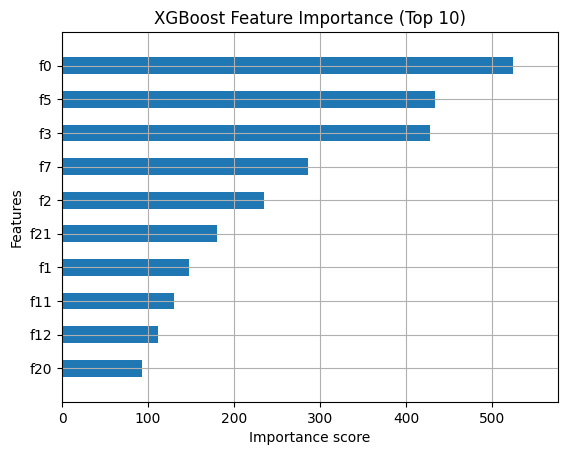


Top 10 Important Features from XGBoost:
     Feature  Importance
18   thal_1    0.403781
11     cp_3    0.083755
8      cp_0    0.066007
21     ca_0    0.061588
16  slope_1    0.037903
20   thal_3    0.036347
1       sex    0.032583
10     cp_2    0.029202
7   oldpeak    0.028314
9      cp_1    0.025825


In [9]:
## Step 4.1: XGBoost Feature Importance
plt.figure(figsize=(10,6))
xgb.plot_importance(xgb_model, importance_type='weight', max_num_features=10,
                    height=0.5, show_values=False)
plt.title("XGBoost Feature Importance (Top 10)")
plt.show()

# Print top 10 features
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print("\nTop 10 Important Features from XGBoost:\n", feature_importance_df.head(10))


## Step 5: Build ANN (Hybrid)

In [10]:
X_train_ann = np.hstack([X_train, xgb_train_pred])
X_test_ann = np.hstack([X_test, xgb_test_pred])

ann_model = Sequential()
ann_model.add(Dense(32, input_dim=X_train_ann.shape[1], activation='relu'))
ann_model.add(Dropout(0.2))
ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = ann_model.fit(
    X_train_ann, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4054 - loss: 0.8312 - val_accuracy: 0.4694 - val_loss: 0.7155
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6029 - loss: 0.6950 - val_accuracy: 0.5306 - val_loss: 0.6917
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6896 - loss: 0.6119 - val_accuracy: 0.7143 - val_loss: 0.6793
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7734 - loss: 0.5420 - val_accuracy: 0.7551 - val_loss: 0.6597
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8585 - loss: 0.4997 - val_accuracy: 0.7755 - val_loss: 0.6489
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8626 - loss: 0.4116 - val_accuracy: 0.7551 - val_loss: 0.6539
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8191 - loss: 0.4218 - val_accuracy: 0.7755 - val_loss: 0.6598
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8138 - loss: 0.3940 - val_accuracy: 0.7755 - 

## Step 5.1: ANN Training History

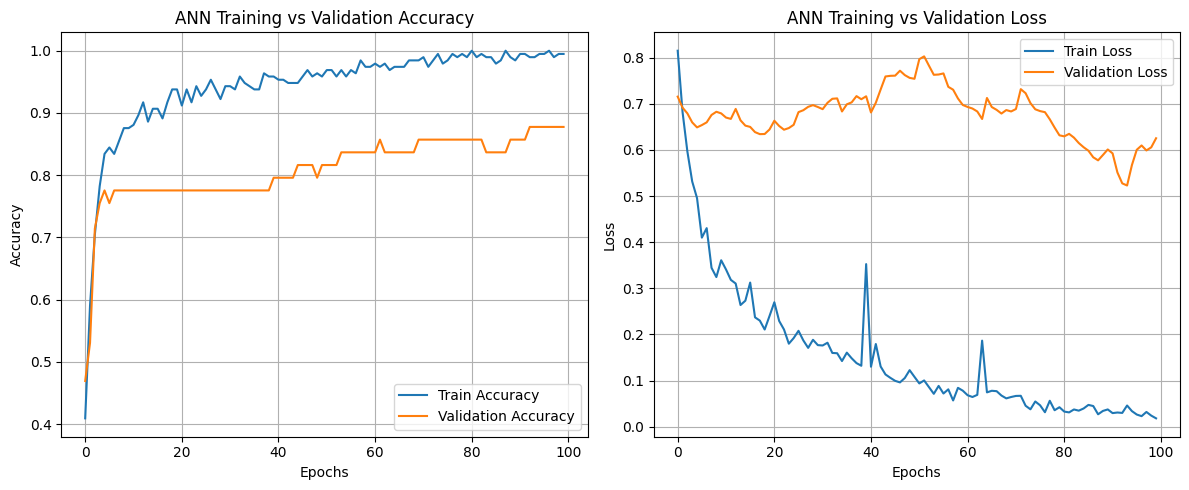

In [11]:
## Step 5.1: ANN Training History
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## Step 6: Evaluate Hybrid Model

In [12]:
## Step 6: Evaluate Hybrid Model
ann_probs = ann_model.predict(X_test_ann)
ann_classes = (ann_probs > 0.5).astype(int)

accuracy = accuracy_score(y_test, ann_classes)
auc_score = roc_auc_score(y_test, ann_probs)

print("Hybrid Model Accuracy:", accuracy)
print("Hybrid Model AUC-ROC:", auc_score)
print("\nClassification Report:\n", classification_report(y_test, ann_classes))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Hybrid Model Accuracy: 0.8852459016393442
Hybrid Model AUC-ROC: 0.9307359307359306

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



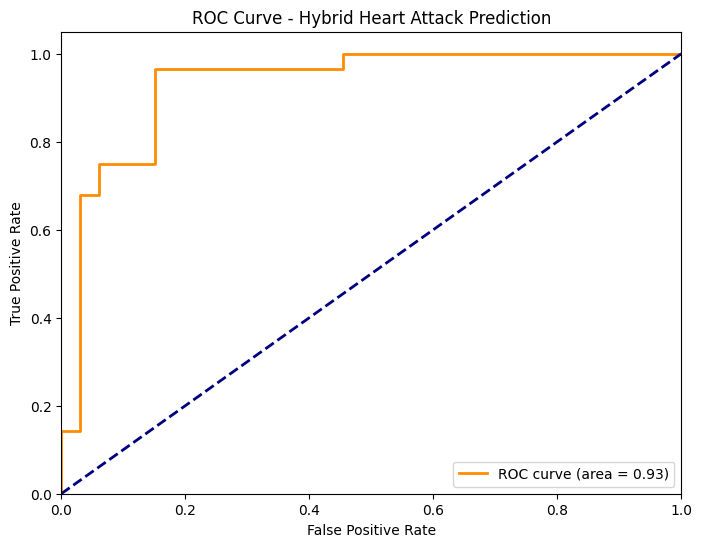

In [13]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, ann_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Hybrid Heart Attack Prediction')
plt.legend(loc="lower right")
plt.show()

## Step 6.1: Confusion Matrix

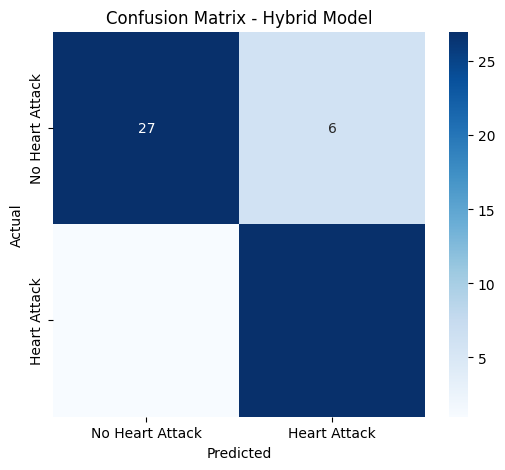

In [14]:
cm = confusion_matrix(y_test, ann_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Heart Attack','Heart Attack'],
            yticklabels=['No Heart Attack','Heart Attack'])
plt.title("Confusion Matrix - Hybrid Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Step 6.2: Precision-Recall Curve

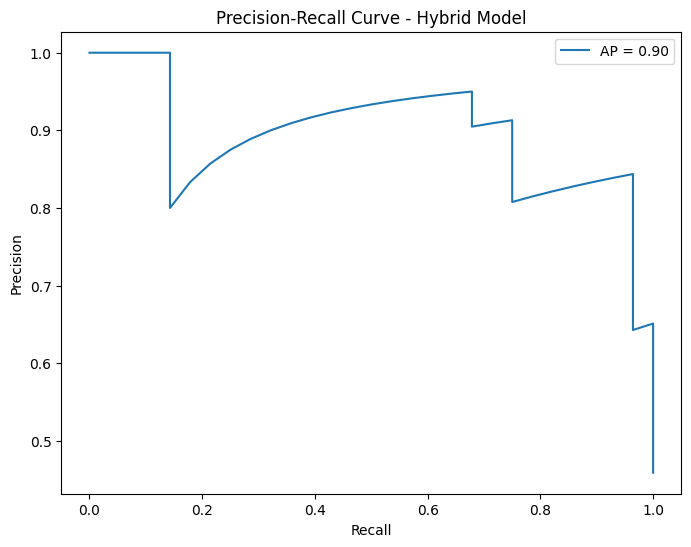

In [15]:
precision, recall, thresholds = precision_recall_curve(y_test, ann_probs)
ap = average_precision_score(y_test, ann_probs)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'AP = {ap:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Hybrid Model')
plt.legend()
plt.show()


## Step 7: Predict New Patient

In [16]:
new_patient = pd.DataFrame([{
    'age': 60, 'sex': 0, 'cp': 2, 'trestbps': 130, 'chol': 210,
    'fbs': 1, 'restecg': 0, 'thalach': 165, 'exang': 1,
    'oldpeak': 1.5, 'slope': 1, 'ca': 1, 'thal': 2
}])

# One-hot encode & align with training features
new_patient = pd.get_dummies(new_patient, columns=categorical_features)
missing_cols = set(X.columns) - set(new_patient.columns)
for c in missing_cols:
    new_patient[c] = 0
new_patient = new_patient[X.columns]

# Scale
new_patient_scaled = scaler.transform(new_patient)

# XGBoost probability
xgb_prob_new = xgb_model.predict_proba(new_patient_scaled)[:,1].reshape(-1,1)

# ANN prediction
new_input_ann = np.hstack([new_patient_scaled, xgb_prob_new])
pred_class = (ann_model.predict(new_input_ann) > 0.5).astype(int)[0][0]
pred_prob = ann_model.predict(new_input_ann)[0][0]

print("Predicted Class (0 = No Heart Attack, 1 = Heart Attack):", pred_class)
print(f"Probability of Heart Attack: {pred_prob:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predicted Class (0 = No Heart Attack, 1 = Heart Attack): 1
Probability of Heart Attack: 0.81


In [18]:
import joblib

# Save
joblib.dump(scaler, "scaler.pkl")
joblib.dump(xgb_model, "xgb_model.pkl")
ann_model.save("ann_model.h5")

# Reload later
scaler = joblib.load("scaler.pkl")
xgb_model = joblib.load("xgb_model.pkl")
ann_model = tf.keras.models.load_model("ann_model.h5")